In [7]:
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.optimize as scippy
import scipy.stats as scist
from numpy.fft import fft, ifft
import os
import shutil
from numba import njit, prange
from scipy.integrate import quad

from matplotlib import animation
from matplotlib.animation import FFMpegWriter
mpl.rcParams['animation.ffmpeg_path'] = r"C:\ffmpeg\bin\ffmpeg.exe"
plt.rc('animation', html='jshtml')

plt.rc("xtick", labelsize=20, top=True, direction="in")
plt.rc("ytick", labelsize=20, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=26)
plt.rc("legend", fontsize=26)

In [8]:
# Simulation parameters
N = 500

sigma = 1.0
rho = 3.0 / (sigma**2)
L = np.sqrt(N / rho)

kappa = 5.5
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
D = kBT / gamma # Diffusion constant via. Einstein-Smoluchowski

U_0 = 2.5
V_0 = U_0 * kBT

F_D = 100.0 # * kBT / sigma

tau = 1.0 * gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 20.0 * tau
t_prod = 00.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

N_save = 10

In [9]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; think it's correct like this
@njit(fastmath=True)
def F_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma * np.exp( -kappa*(r-sigma) ) * (kappa*r + 1) / r**2
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            fx = F_mag * dx / r
            fy = F_mag * dy / r

            # Apply Newton's third law / symmetry of the force matrix:
            forces[i, 0] += fx
            forces[i, 1] += fy

            forces[j, 0] -= fx
            forces[j, 1] -= fy
        
        epsilon = 1e-12*sigma # Add tiny seperation to avoid problems with particle starting in the middle
        # Seperation to the big repulsive circle in the middle
        x_circ = min_image(xi - L/2, L) + epsilon
        y_circ = min_image(yi - L/2, L) + epsilon
        r_circ = np.sqrt(x_circ*x_circ + y_circ*y_circ)

        F_mag_circ = 50.0*F_Yuk(r_circ) # (1.0/3.0) *

        fx_circ = F_mag_circ * x_circ / r_circ
        fy_circ = F_mag_circ * y_circ / r_circ

        forces[i, 0] += fx_circ
        forces[i, 1] += fy_circ
            
    return forces

# Brownian Dynamics integration step with only the Yukawa force
# @njit(fastmath=True)
# def bd_step_equil(pos):
#     F_matrix = compute_forces(pos)
#     noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
#     pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

#     return pos

# Brownian Dynamics integration step with species-based external driving
@njit(fastmath=True)
def bd_step_drive(pos, species):
    F_matrix = compute_forces(pos)
    F_matrix[:,0] += species * F_D # # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

#MSD computation
@njit(fastmath=True)
def compute_msd(pos, pos0):
    msd = 0.0

    for i in range(N):
        dx = pos[i, 0] - pos0[i, 0]
        dy = pos[i, 1] - pos0[i, 1]

        # minimum image convention
        # dx -= L * np.round(dx / L)
        # dy -= L * np.round(dy / L)

        msd += dx*dx + dy*dy

    return msd / N

r_l = 1/(2*np.sqrt(rho))
# Order parameter computation for SEPERATED left-right flag lists
# def compute_Phi(list_L, list_R):
#     Phi = 0.0

#     # Essentially just checks for each 'left' particle whether there exists a 'right' particle s.t. the criteria 'fails',
#     # and phi=0 for the left particle
#     for part in list_L:
#         phi = 1.0 # Candidate for ordered particle
#         for test in list_R:
#             sep_vec = part - test
#             sep_vec_image = sep_vec - L * np.round(sep_vec / L) # minimum image
#             sep = np.linalg.norm(sep_vec_image)
#             if sep <= r_l:
#                 phi = 0.0
#         Phi += phi
    
#     # Same deal for the right particles being tested
#     for part in list_R:
#         phi = 1.0 # Candidate for ordered particle
#         for test in list_L:
#             sep_vec = part - test
#             sep_vec_image = sep_vec - L * np.round(sep_vec / L) # minimum image
#             sep = np.linalg.norm(sep_vec_image)
#             if sep <= r_l:
#                 phi = 0.0
#         Phi += phi
    
#     Phi = Phi / N
#     return Phi

def compute_Phi(list_L, list_R):
    Phi = 0.0

    # Left particles tested against right particles
    for part in list_L:
        phi = 1.0
        yi = part[1]

        for test in list_R:
            dy = yi - test[1]
            dy -= L * np.round(dy / L)   # minimum image in y only

            if abs(dy) <= r_l:            # same criterion as compute_phi
                phi = 0.0
                break

        Phi += phi

    # Right particles tested against left particles
    for part in list_R:
        phi = 1.0
        yi = part[1]

        for test in list_L:
            dy = yi - test[1]
            dy -= L * np.round(dy / L)   # minimum image in y only

            if abs(dy) <= r_l:
                phi = 0.0
                break

        Phi += phi

    Phi /= N
    return Phi

# Simply take a step to do velocities as finite-difference, the 1dt timestep isn't saved
def compute_velocities(pos, species):
    pos_t = pos.copy()
    pos = bd_step_drive(pos, species)
    velocities = (pos - pos_t) / dt
    return np.abs(velocities)

def compute_velocities_x(pos, species):
    pos_t = pos.copy()
    pos_t = np.array([pos_t[i, 0] for i in range(len(pos_t))])
    pos = bd_step_drive(pos, species)
    pos = np.array([pos[i, 0] for i in range(len(pos_t))])
    velocities = (pos - pos_t) / dt
    return np.abs(velocities)

In [10]:
pos = init_grid(L, N)

# Species labels f_i = ±1
species = np.ones(N)
species[:N // 2] = -1
np.random.shuffle(species)

print("Running equilibration period ...")

# Equilibration
for step in range(n_steps_equil):
    pos = bd_step_drive(pos, species)

print("Equilibration done.")

# Main simulation
v_R_avs = []
print("Running measurement period ...")
for step in range(n_steps_prod):
        pos = bd_step_drive(pos, species)

        if step % (n_steps_prod // N_save) == 0:
                print(f"Progress: {100 * step / n_steps_prod:.0f}%")

print("Measurement run finished.")

pos_L = pos[species==-1]
pos_R = pos[species==1]

pos_L_image = pos_L.copy()
pos_L_image %= L

pos_R_image = pos_R.copy()
pos_R_image %= L

Running equilibration period ...
Equilibration done.
Running measurement period ...
Measurement run finished.


In [11]:
# fig, ax = plt.subplots(figsize=(10, 10))

# ax.scatter(pos_L_image[:, 0], pos_L_image[:, 1], label='Left movers')
# ax.scatter(pos_R_image[:, 0], pos_R_image[:, 1], label='Right movers')

# circle = plt.Circle(
#     (L/2, L/2), # Center
#     1*sigma, # Radius; note that it's meaningless since it's Yukawa repulsive and not a hard shell
#     fill=False,      # Transparent in middle so we can see if there are particles or not
#     edgecolor = 'k',
#     linewidth = 2
# )
# ax.add_patch(circle)

# ax.set_aspect('equal')
# ax.legend(bbox_to_anchor=(1, 1))
# fig.tight_layout()

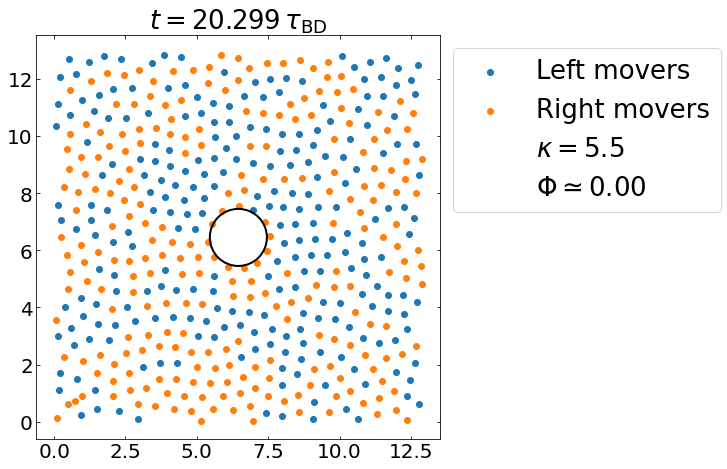

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

leftplot = ax.scatter(pos_L_image[:, 0], pos_L_image[:, 1], label='Left movers')
rightplot = ax.scatter(pos_R_image[:, 0], pos_R_image[:, 1], label='Right movers')

starttime = (t_equil + t_prod) / tau # Measured in units of tau
time_text = ax.set_title(rf"$t = {starttime:.3f}\,\tau_\mathrm{{BD}}$")

circle = plt.Circle(
    (L/2, L/2), # Center
    1*sigma, # Radius; note that it's meaningless since it's Yukawa repulsive and not a hard shell
    fill=False,      # Transparent in middle so we can see if there are particles or not
    edgecolor = 'k',
    linewidth = 2
)
ax.add_patch(circle)

Phi = compute_Phi(pos_L, pos_R)
text_lines = [
    Line2D([], [], color='none',
           label=rf'$\kappa = {kappa}$'),
    Line2D([], [], color='none',
           label=rf'$\Phi \simeq {Phi:.2f}$')
]

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1, 1), handles=[leftplot, rightplot, *text_lines])
fig.tight_layout()

def update(i):
    global pos
    increment = 10
    
    # Make the steps more than one dt so it's easier too see something, i.e. speed up the timescale of the animation
    for _ in range(increment):
        pos = bd_step_drive(pos, species)

    # Woefully inefficient, but quick solution to just re-do the L-R lists for each frame of animation
    pos_L = pos[species==-1]
    pos_R = pos[species==1]
    
    pos_L_image = pos_L.copy()
    pos_L_image %= L

    pos_R_image = pos_R.copy()
    pos_R_image %= L

    leftplot.set_offsets(pos_L_image)
    rightplot.set_offsets(pos_R_image)

    time = starttime + i * increment * dt / tau
    time_text.set_text(rf"$t = {time:.3f}\,\tau_\mathrm{{BD}}$")

    return leftplot, rightplot, time_text

anim = animation.FuncAnimation(
    fig,
    update,
    frames=300,
    interval=30,
    blit=False
)

writer = FFMpegWriter(
    fps=30,
    metadata=dict(artist='You'),
    bitrate=2000
)

anim.save(rf"../Animations/Task5_kappa={kappa}.mp4")